# 02 — Bayesian uncertainty and top-K rankings

This notebook focuses on posterior uncertainty, credible intervals, and top-K high-risk probabilities. It is useful for policy-facing interpretation.

In [1]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# This lets the notebook work whether it is launched from the project root or from notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)


def read_json(path):
    path = Path(path)
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing expected file: {path}")
    return path


def load_csv(relative_path, **kwargs):
    path = require_file(OUTPUTS / relative_path)
    return pd.read_csv(path, **kwargs)


def savefig(name):
    path = FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved figure: {path}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs folder: {OUTPUTS}")


Project root: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project
Outputs folder: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs


## Load Bayesian spatial outputs

In [2]:

rates = load_csv("bayes_spatial/bayesian_spatial_posterior_rates.csv")
topk = load_csv("bayes_spatial/bayesian_spatial_top_k_probabilities.csv")
modeled = load_csv("modeled_dataset.csv")

for df in [rates, topk, modeled]:
    df["geo_id"] = df["geo_id"].astype(str)

df = rates.merge(topk, on="geo_id", how="left").merge(
    modeled[["geo_id", "population", "outcome_count", "observed_rate_per_100k", "model_inclusion_flag"]],
    on="geo_id", how="left"
)
df["ci_width"] = df["bayes_spatial_predicted_rate_ci_upper"] - df["bayes_spatial_predicted_rate_ci_lower"]
df["relative_ci_width"] = df["ci_width"] / df["bayes_spatial_predicted_rate_mean_per_100k"]
df.head()


,geo_id,bayes_spatial_predicted_rate_mean_per_100k,bayes_spatial_predicted_rate_ci_lower,bayes_spatial_predicted_rate_ci_upper,bayes_spatial_predicted_count_mean,bayes_spatial_top_k_probability,top_k,n_posterior_draws,population,outcome_count,observed_rate_per_100k,model_inclusion_flag,ci_width,relative_ci_width
0,24042,66.922457,42.658086,100.303335,4.600919,0.0000,10,2000,6875,4.0,58.181818,1,57.645249,0.861374
1,24046,56.051418,26.493547,104.277738,5.164017,0.0035,10,2000,9213,6.0,65.125366,1,77.784191,1.387729
2,24002,87.563060,59.243861,125.470751,3.500771,0.0020,10,2000,3998,3.0,75.037519,1,66.226890,0.756334
3,24003,47.435454,29.824250,71.452169,11.548636,0.0000,10,2000,24346,10.0,41.074509,1,41.627919,0.877570
4,24004,176.243930,94.759684,297.900651,3.553078,0.7225,10,2000,2016,3.0,148.809524,1,203.140966,1.152613


## Highest posterior mean risks

In [3]:

cols = [
    "geo_id", "population", "observed_rate_per_100k",
    "bayes_spatial_predicted_rate_mean_per_100k",
    "bayes_spatial_predicted_rate_ci_lower",
    "bayes_spatial_predicted_rate_ci_upper",
    "ci_width", "bayes_spatial_top_k_probability",
]
df.sort_values("bayes_spatial_predicted_rate_mean_per_100k", ascending=False)[cols].head(15)


,geo_id,population,observed_rate_per_100k,bayes_spatial_predicted_rate_mean_per_100k,bayes_spatial_predicted_rate_ci_lower,bayes_spatial_predicted_rate_ci_upper,ci_width,bayes_spatial_top_k_probability
46,24030,2408,290.697674,248.338515,116.001889,498.485006,382.483117,0.9255
48,24028,471011,264.112728,224.241130,115.928737,417.007853,301.079116,0.8720
51,24024,50900,153.241650,207.569296,78.857575,524.876593,446.019019,0.6750
6,24019,2723,183.621006,204.013119,107.036627,341.550679,234.514053,0.8560
4,24004,2016,148.809524,176.243930,94.759684,297.900651,203.140966,0.7225
29,24043,4246,117.757890,168.000306,91.621851,277.429416,185.807565,0.7150
9,24045,7172,153.374233,158.133258,68.605966,316.363531,247.757565,0.5050
28,24013,93009,204.281306,153.388831,91.664336,254.158847,162.494511,0.5330
20,24051,7803,192.233756,150.128881,89.098748,242.248463,153.149715,0.5195
56,24047,4646,64.571675,142.503227,81.661856,223.633892,141.972036,0.4430


## Most certain and most uncertain predictions

In [4]:

print("Narrowest relative credible intervals")
display(df.sort_values("relative_ci_width")[cols + ["relative_ci_width"]].head(10))

print("Widest relative credible intervals")
display(df.sort_values("relative_ci_width", ascending=False)[cols + ["relative_ci_width"]].head(10))


Narrowest relative credible intervals


,geo_id,population,observed_rate_per_100k,bayes_spatial_predicted_rate_mean_per_100k,bayes_spatial_predicted_rate_ci_lower,bayes_spatial_predicted_rate_ci_upper,ci_width,bayes_spatial_top_k_probability,relative_ci_width
42,24036,14438,83.114005,91.190620,62.646250,129.982028,67.335777,0.0060,0.738407
52,24023,7843,63.751116,126.578451,83.853213,178.679672,94.826460,0.1735,0.749152
2,24002,3998,75.037519,87.563060,59.243861,125.470751,66.226890,0.0020,0.756334
31,24011,24663,125.694360,120.517127,79.487899,176.664965,97.177066,0.1235,0.806334
38,24039,6848,87.616822,59.368153,39.536282,88.369220,48.832938,0.0010,0.822544
30,24012,10299,67.967764,63.258682,40.118444,92.409111,52.290667,0.0000,0.826616
50,24005,9582,166.979754,122.529424,81.389674,182.773786,101.384112,0.1620,0.827427
36,24041,9097,76.948445,66.183631,43.019199,98.318591,55.299393,0.0005,0.835545
49,24026,4678,0.000000,61.361646,37.277915,89.886032,52.608117,0.0005,0.857345
0,24042,6875,58.181818,66.922457,42.658086,100.303335,57.645249,0.0000,0.861374


Widest relative credible intervals


,geo_id,population,observed_rate_per_100k,bayes_spatial_predicted_rate_mean_per_100k,bayes_spatial_predicted_rate_ci_lower,bayes_spatial_predicted_rate_ci_upper,ci_width,bayes_spatial_top_k_probability,relative_ci_width
33,24009,2497,80.096115,89.446692,20.596793,256.574337,235.977544,0.1355,2.638192
27,24015,11158,44.810898,59.438030,15.914724,167.129400,151.214676,0.0360,2.544073
51,24024,50900,153.241650,207.569296,78.857575,524.876593,446.019019,0.6750,2.148772
55,24017,12608,NaN,130.050589,47.877009,287.099085,239.222076,0.3115,1.839454
5,24018,7852,25.471218,85.486761,31.900272,182.123117,150.222845,0.0805,1.757264
9,24045,7172,153.374233,158.133258,68.605966,316.363531,247.757565,0.5050,1.566764
46,24030,2408,290.697674,248.338515,116.001889,498.485006,382.483117,0.9255,1.540168
43,24035,170195,76.970534,119.890354,57.104277,238.344111,181.239835,0.2320,1.511713
15,24055,13904,28.768700,57.220764,25.741374,110.820793,85.079419,0.0040,1.486863
41,24037,48828,65.536168,84.278591,39.613533,164.479581,124.866048,0.0545,1.481587


## Credible-interval plot for top-risk municipalities

Saved figure: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs\figures\02_top15_bayes_spatial_intervals.png


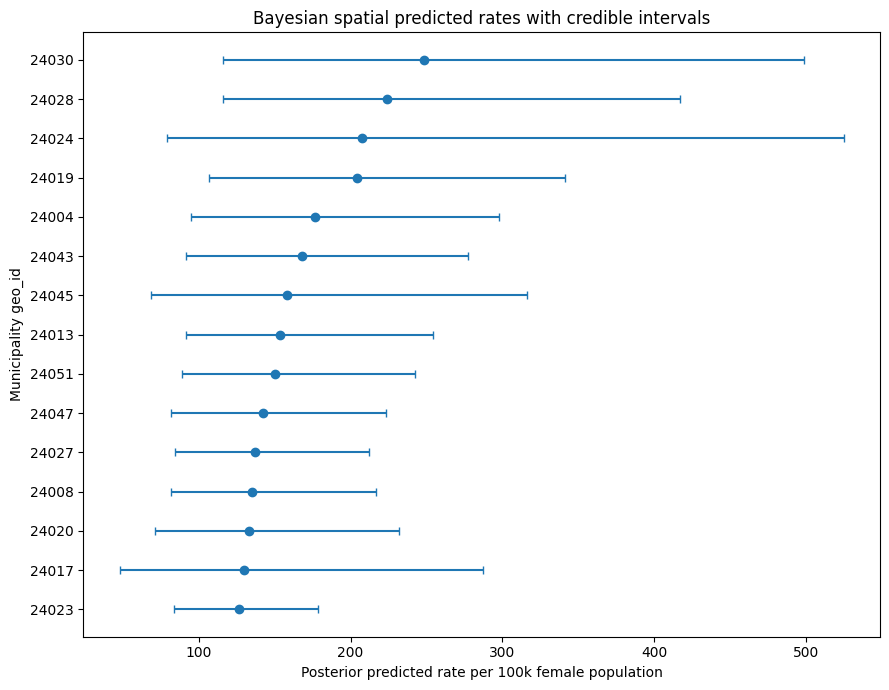

In [5]:

plot_df = df.sort_values("bayes_spatial_predicted_rate_mean_per_100k", ascending=False).head(15).copy()
plot_df = plot_df.sort_values("bayes_spatial_predicted_rate_mean_per_100k")

x = plot_df["bayes_spatial_predicted_rate_mean_per_100k"]
xerr = np.vstack([
    x - plot_df["bayes_spatial_predicted_rate_ci_lower"],
    plot_df["bayes_spatial_predicted_rate_ci_upper"] - x,
])

fig, ax = plt.subplots(figsize=(9, 7))
ax.errorbar(x, plot_df["geo_id"], xerr=xerr, fmt="o", capsize=3)
ax.set_xlabel("Posterior predicted rate per 100k female population")
ax.set_ylabel("Municipality geo_id")
ax.set_title("Bayesian spatial predicted rates with credible intervals")
savefig("02_top15_bayes_spatial_intervals.png")
plt.show()


## Top-K posterior probabilities

Saved figure: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs\figures\02_topk_probabilities.png


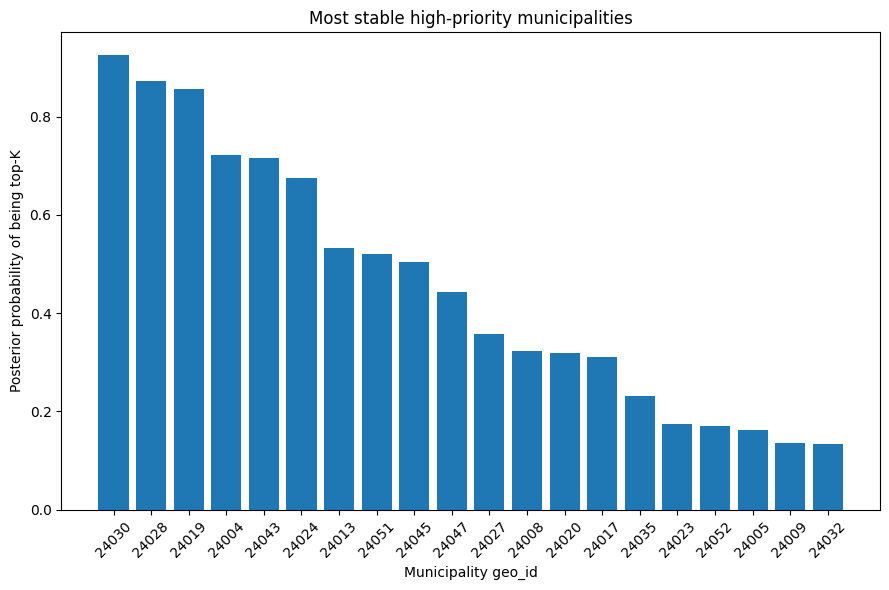

In [6]:

plot_df = df.sort_values("bayes_spatial_top_k_probability", ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(plot_df["geo_id"], plot_df["bayes_spatial_top_k_probability"])
ax.set_xlabel("Municipality geo_id")
ax.set_ylabel("Posterior probability of being top-K")
ax.set_title("Most stable high-priority municipalities")
ax.tick_params(axis="x", rotation=45)
savefig("02_topk_probabilities.png")
plt.show()


## Risk vs uncertainty

Areas in the upper-right are high predicted risk and high uncertainty. These can be useful candidates for better data collection or validation.

Saved figure: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs\figures\02_risk_vs_uncertainty.png


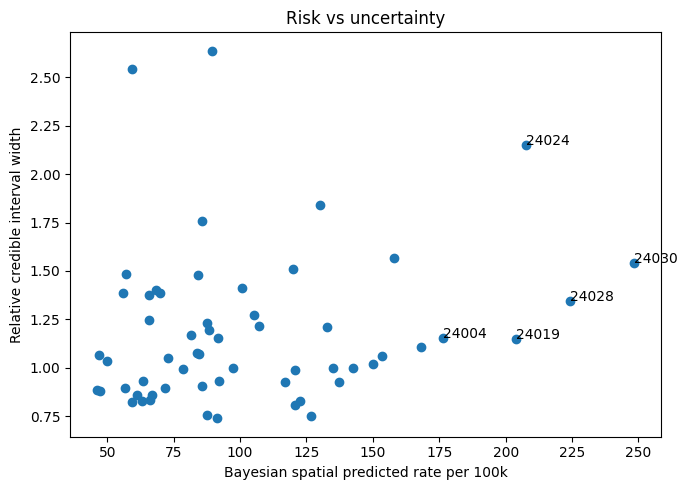

In [7]:

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["bayes_spatial_predicted_rate_mean_per_100k"], df["relative_ci_width"])
ax.set_xlabel("Bayesian spatial predicted rate per 100k")
ax.set_ylabel("Relative credible interval width")
ax.set_title("Risk vs uncertainty")
for _, row in df.sort_values("bayes_spatial_predicted_rate_mean_per_100k", ascending=False).head(5).iterrows():
    ax.annotate(row["geo_id"], (row["bayes_spatial_predicted_rate_mean_per_100k"], row["relative_ci_width"]))
savefig("02_risk_vs_uncertainty.png")
plt.show()


## Interpretation reminder

Top-K probability is often more useful than raw rank. A municipality with a high posterior mean but a low top-K probability is less stable than a municipality that repeatedly appears in the top-K across posterior draws.